In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded! ✅")

Libraries loaded! ✅


In [2]:
df = pd.read_csv('/Users/abhinavjha/NeuralRetail/data/processed/clean_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max()
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
    }).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
print(f"RFM shape: {rfm.shape} ✅")
rfm.head()


RFM shape: (4339, 4) ✅


,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [3]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)
print("Segments created! ✅")
print(rfm['Segment'].value_counts())


Segments created! ✅
Segment
3    3053
1    1062
0     211
2      13
Name: count, dtype: int64


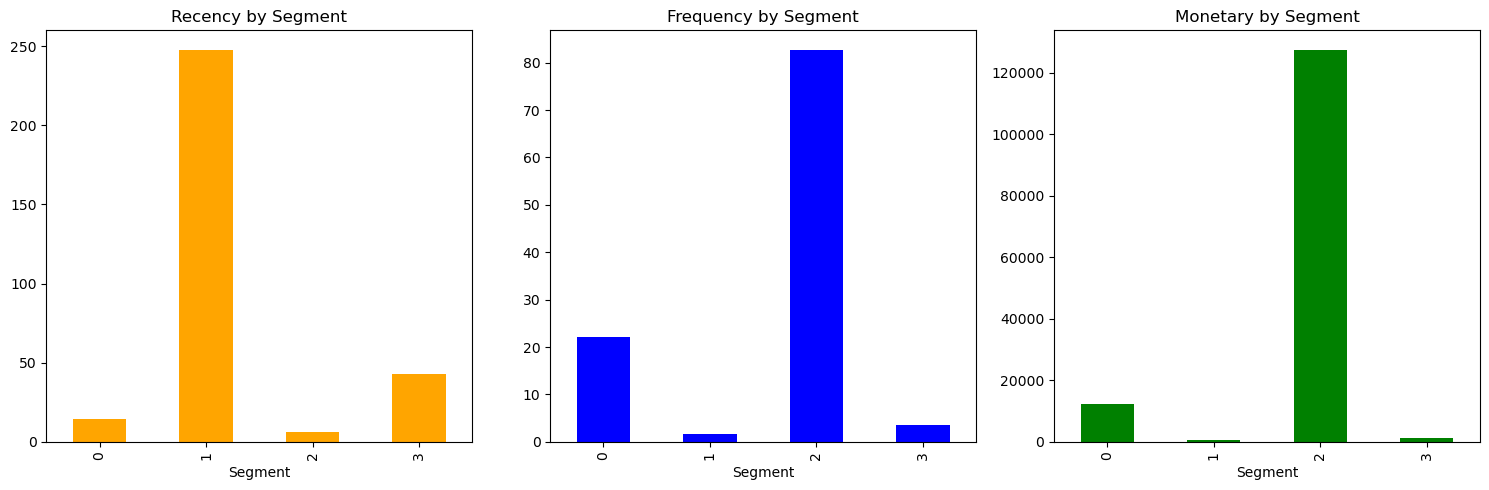

Segmentation charts done! ✅


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rfm.groupby('Segment')['Recency'].mean().plot(kind='bar', ax=axes[0], title='Recency by Segment', color='orange')
rfm.groupby('Segment')['Frequency'].mean().plot(kind='bar', ax=axes[1], title='Frequency by Segment', color='blue')
rfm.groupby('Segment')['Monetary'].mean().plot(kind='bar', ax=axes[2], title='Monetary by Segment', color='green')
plt.tight_layout()
plt.show()
print("Segmentation charts done! ✅")

In [5]:
rfm.to_csv('/Users/abhinavjha/NeuralRetail/data/processed/customer_segments.csv', index=False)
print("Segments saved! ✅")

Segments saved! ✅
